In [2]:
import sys
sys.path.append('../')
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from qiskit.quantum_info import SparsePauliOp
import matplotlib.pyplot as plt

In [33]:
tp = PauliRepresentation.from_pauli_list(PauliList('XYZII'))
# print(PauliList('XYZII')._z)
print('weight of single Pauli: ', tp.weights)

# Create some Pauli operators
paulis = PauliList(['XYZII', 'IIIII', 'ZZZZZ', 'XXIII'])
# Convert to PauliRepresentation
pauli_rep = PauliRepresentation.from_pauli_list(paulis)
print('number of Paulis:', pauli_rep.n_pauli)
print('bit rep: ', pauli_rep.bits)
print('weights: ', pauli_rep.weights)
print('coeffs: ', pauli_rep.coeffs)

# Get weights efficiently
weights = pauli_rep.weight()
print(f"Weights: {weights}")  # Output: Weights: [3 0 5 2]
print('anticommutes: ', pauli_rep.anticommutes(tp))
print('indices (anti):', np.where(pauli_rep.anticommutes(tp))[0])

weight of single Pauli:  3
number of Paulis: 4
bit rep:  [[12 24]
 [ 0  0]
 [31  0]
 [ 0 24]]
weights:  [3 0 5 2]
coeffs:  [1.+0.j]
Weights: [3 0 5 2]
anticommutes:  [False False False  True]
indices (anti): [3]


In [35]:
gx = 1.4
gz = 0.9045
nsites = 21
hx = SparsePauliOp.from_sparse_list([('X', [i], gx) for i in range(nsites)], num_qubits=nsites)
hz = SparsePauliOp.from_sparse_list([('Z', [i], gz) for i in range(nsites)], num_qubits=nsites)
hzz = SparsePauliOp.from_sparse_list([('ZZ', [i, i+1], 1.0) for i in range(nsites-1)], num_qubits=nsites)
print(hx._pauli_list)
print(hx._coeffs)
hi = [hx[0] + hz[0] + hzz[0]/2] + [hx[i] + hz[i] + hzz[i-1] / 2 + hzz[i] / 2 for i in range(1, nsites-1)] + [hx[nsites-1] + hz[nsites-1] + hzz[nsites-2]/2]
# print(hi)

def exp_val_func(observable):
    return [observable.overlap(PauliRepresentation.from_sparse_pauli_op(h)) for h in hi]

def msd(a):
    j = np.arange(1,len(a)+1)
    return np.sum(a*j**2) - np.sum(a*j)**2

['IIIIIIIIIIIIIIIIIIIIX', 'IIIIIIIIIIIIIIIIIIIXI',
 'IIIIIIIIIIIIIIIIIIXII', 'IIIIIIIIIIIIIIIIIXIII',
 'IIIIIIIIIIIIIIIIXIIII', 'IIIIIIIIIIIIIIIXIIIII',
 'IIIIIIIIIIIIIIXIIIIII', 'IIIIIIIIIIIIIXIIIIIII',
 'IIIIIIIIIIIIXIIIIIIII', 'IIIIIIIIIIIXIIIIIIIII',
 'IIIIIIIIIIXIIIIIIIIII', 'IIIIIIIIIXIIIIIIIIIII',
 'IIIIIIIIXIIIIIIIIIIII', 'IIIIIIIXIIIIIIIIIIIII',
 'IIIIIIXIIIIIIIIIIIIII', 'IIIIIXIIIIIIIIIIIIIII',
 'IIIIXIIIIIIIIIIIIIIII', 'IIIXIIIIIIIIIIIIIIIII',
 'IIXIIIIIIIIIIIIIIIIII', 'IXIIIIIIIIIIIIIIIIIII',
 'XIIIIIIIIIIIIIIIIIIII']
[1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j
 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j
 1.4+0.j 1.4+0.j 1.4+0.j]


In [23]:
dt = 0.01
nsteps = 300
threshold = 0.0001
ops = dt*(hz + hzz + hx)
obs = hi[(nsites-1)//2]
print('obs:', obs)

obs: SparsePauliOp(['IIIIIIIIIIXIIIIIIIIII', 'IIIIIIIIIIZIIIIIIIIII', 'IIIIIIIIIIZZIIIIIIIII', 'IIIIIIIIIZZIIIIIIIIII'],
              coeffs=[1.4   +0.j, 0.9045+0.j, 0.5   +0.j, 0.5   +0.j])


In [29]:
sim = Simulation.from_pauli_list(obs, ops, threshold=threshold, nprocs=8)
r = sim.run_dynamics(nsteps, process=exp_val_func, process_every = 10)
r = np.array(r)
r = r / r[0].sum()
print(sim.observable.size(), np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs))
d2 = [msd(ri) for ri in r]

214885 0.9768794703586717


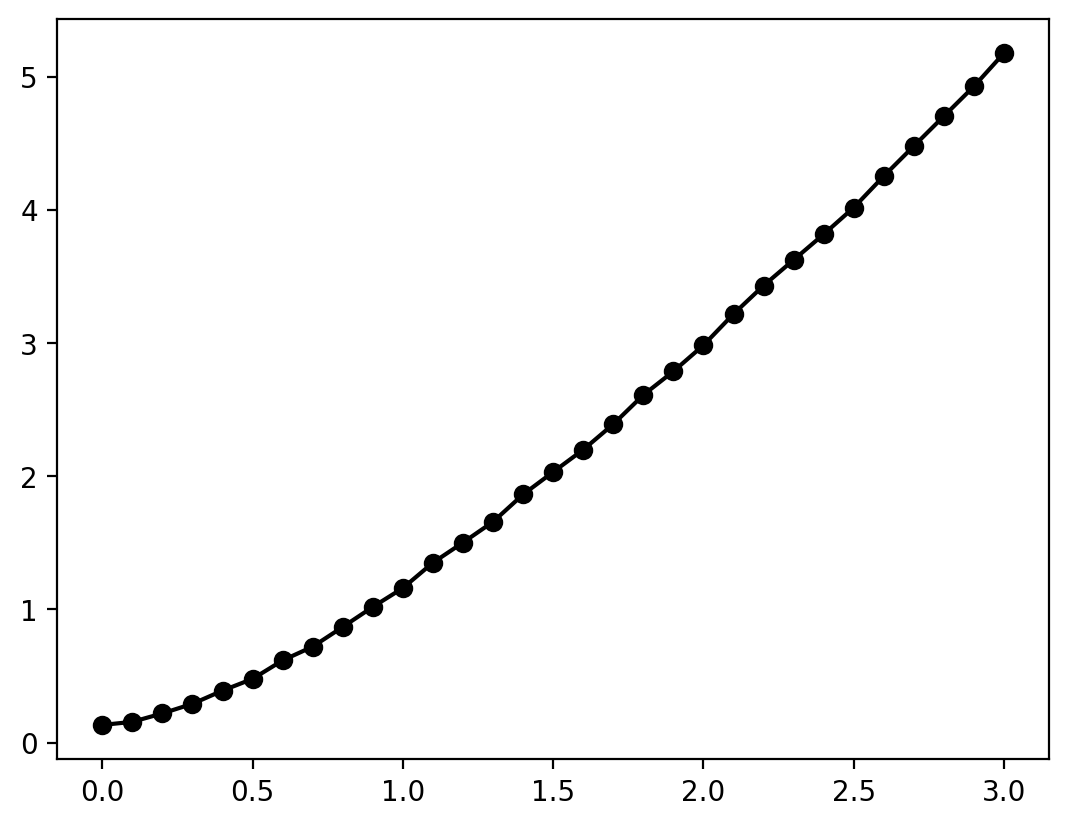

In [26]:
fig, ax = plt.subplots(1, 1)
ax.plot(np.arange(len(d2))/10, abs(np.array(d2)), '-ok')
# ax.set_ylim(0, 7)
plt.show()